# **Regression: Random Forest Regressor (RFR)**

## **Justification of Preprocessing Strategy**

### **Scale Invariance**
The Random Forest Regressor is an ensemble method built entirely upon Decision Trees. Because individual trees partition data based on discrete threshold rules (e.g., `BMI > 30`) rather than calculating geometric distances, the entire ensemble inherits this mathematical scale-invariance. Standardization or Normalization will not alter the model's splitting logic or improve predictive performance. To preserve clinical interpretability and maximize computational efficiency, we will train the model using the **Original, Unscaled Data**.

### **Architectural Knowledge Transfer (Structural Regularization)**
By default, Scikit-Learn's Random Forest allows base trees to grow unconstrained (`max_depth=None`), which inevitably leads to severe memorization (Overfitting) on a 100,000-row dataset. Instead of starting blind, we will apply **Architectural Knowledge Transfer**. We extract the structural boundaries discovered in our standalone Decision Tree Regressor champion (`max_depth=20`, `min_samples_leaf=10`, `min_samples_split=10`) and inject them as the foundational blueprint for every tree in our forest. This guarantees a mathematically safe baseline.

## **Experiment Design**

We designed a tournament of 3 optimization levels. We strictly log **both Train and Test metrics (RMSE, MAE, R²)** to explicitly monitor the Overfitting Gap:

* **Architectural Baseline**: 100 trees built using the exact structural parameters of our Decision Tree champion, establishing a robust, pre-regularized performance floor.
* **GridSearchCV**: A highly targeted 3-fold cross-validated search exploring around our champion's boundaries. We focus primarily on ensemble-specific mechanisms such as `max_features` (to decorrelate the trees) and ensemble size (`n_estimators`).
* **Optuna Optimization**: Bayesian optimization utilizing a safe trial budget to explore the continuous parameter space around our champion's depth and leaf constraints, while introducing data starvation (`max_samples`) to maximize ensemble diversity and minimize the validation RMSE.

[I 2026-05-22 22:15:03,650] A new study created in memory with name: no-name-1a027943-9f96-4537-97fa-e5e736f19bc9
[I 2026-05-22 22:15:07,524] Trial 0 finished with value: 2.0195870569681706 and parameters: {'n_estimators': 107, 'max_depth': 18, 'min_samples_leaf': 14, 'min_samples_split': 24, 'max_features': 'sqrt', 'max_samples': 0.7140135838925628}. Best is trial 0 with value: 2.0195870569681706.
[I 2026-05-22 22:15:11,613] Trial 1 finished with value: 2.4971995033139485 and parameters: {'n_estimators': 146, 'max_depth': 12, 'min_samples_leaf': 9, 'min_samples_split': 10, 'max_features': 'log2', 'max_samples': 0.8508447767676212}. Best is trial 0 with value: 2.0195870569681706.
[I 2026-05-22 22:15:18,835] Trial 2 finished with value: 1.95343296975153 and parameters: {'n_estimators': 193, 'max_depth': 21, 'min_samples_leaf': 13, 'min_samples_split': 27, 'max_features': 'sqrt', 'max_samples': 0.8020684492444206}. Best is trial 2 with value: 1.95343296975153.
[I 2026-05-22 22:15:23,860]

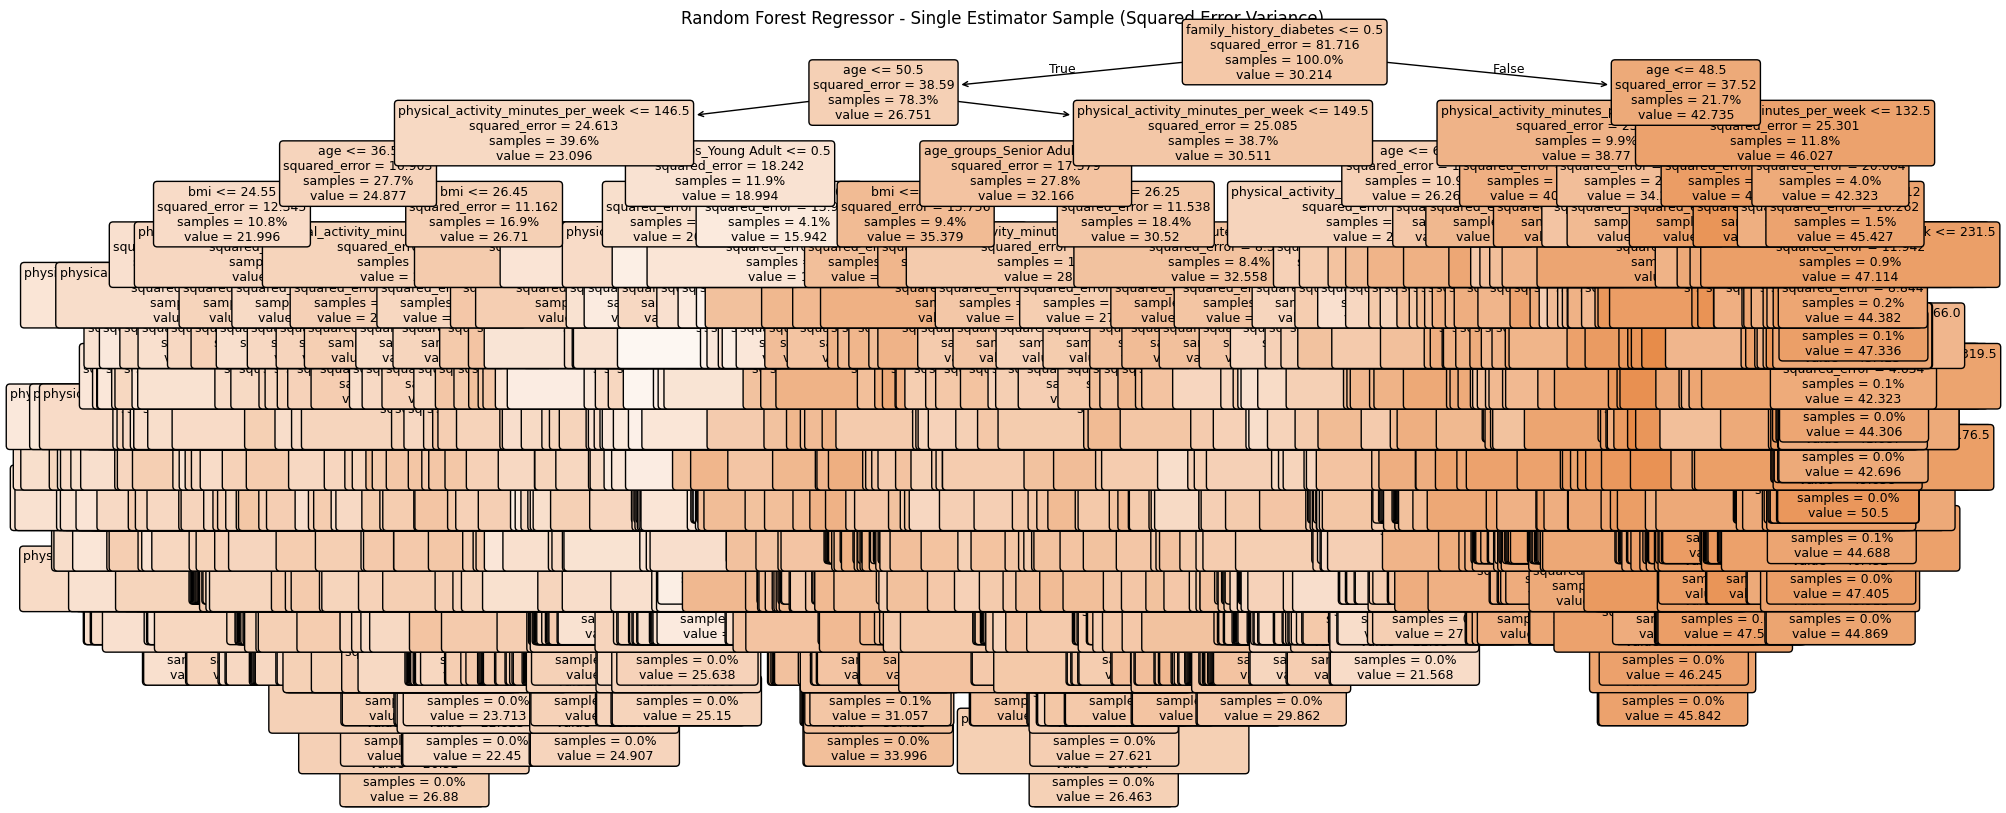

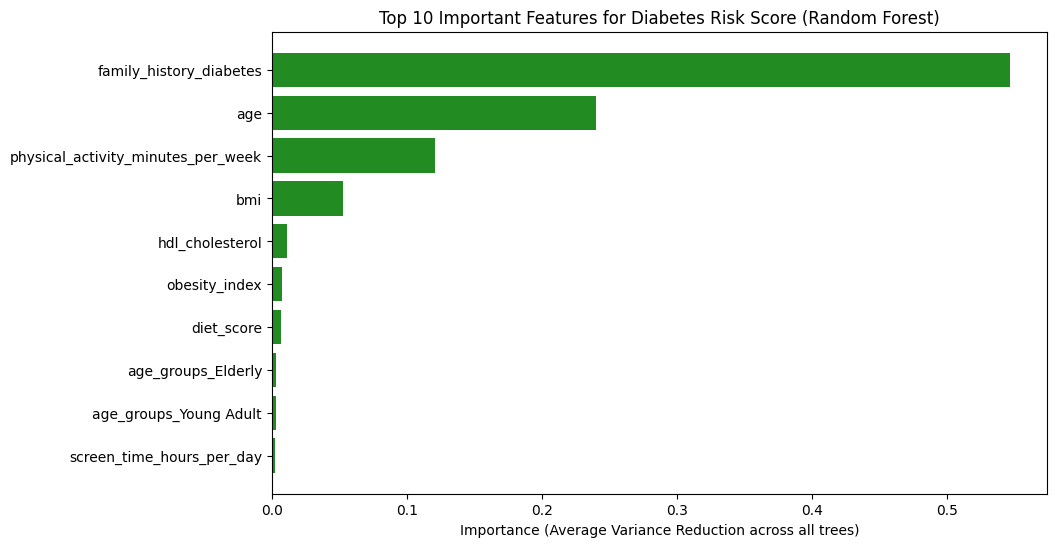

In [3]:
import pandas as pd
import numpy as np
import time
import mlflow
import optuna
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import plot_tree

# 1. MLflow Configuration
mlflow.set_tracking_uri("sqlite:///C:/Users/Tiago Silva/Uni/OneDrive - Universidade Portucalense/Ambiente de Trabalho/Uni/3ano2sem/LAD/Grupo5_ProjetoLAD_Parte2/TrabalhoLAD/models/mlflow.db")
mlflow.set_experiment("Regression_RandomForest")

# 2. Data Loading and Preparation
df = pd.read_csv("C:\\Users\\Tiago Silva\\Uni\\OneDrive - Universidade Portucalense\\Ambiente de Trabalho\\Uni\\3ano2sem\\LAD\\Grupo5_ProjetoLAD_Parte2\\TrabalhoLAD\\data\\diabetes_dataset_new_variables.csv")

categorical_cols = [
    'gender', 'ethnicity', 'smoking_status', 'education_level',
    'employment_status', 'age_groups', 'weight_status', 'income_level'
]

# Apply One-Hot Encoding
df_final = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separate features and target 
# Drop classification targets to prevent data leakage!
X = df_final.drop(["diagnosed_diabetes", "diabetes_stage", "diabetes_risk_score"], axis=1)
y = df_final['diabetes_risk_score']

# Split data (80/20) - No stratify needed for continuous targets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

SEED = 42

def log_regression_metrics(y_tr_true, y_tr_pred, y_te_true, y_te_pred, duration):
    # Logs Train and Test metrics explicitly to monitor the Overfitting Gap
    # Train Partition Metrics
    mlflow.log_metric("rmse_train", mean_squared_error(y_tr_true, y_tr_pred) ** 0.5)
    mlflow.log_metric("mae_train", mean_absolute_error(y_tr_true, y_tr_pred))
    mlflow.log_metric("r2_train", r2_score(y_tr_true, y_tr_pred))
    
    # Test Partition Metrics
    mlflow.log_metric("rmse_test", mean_squared_error(y_te_true, y_te_pred) ** 0.5)
    mlflow.log_metric("mae_test", mean_absolute_error(y_te_true, y_te_pred))
    mlflow.log_metric("r2_test", r2_score(y_te_true, y_te_pred))
    
    mlflow.log_metric("fit_time", duration)

# ---------------------------------------------------------
# RUN 1: BASELINE 
# ---------------------------------------------------------
with mlflow.start_run(run_name="RFR_Baseline_Architectural"):
    # Injecting the Decision Tree Champion parameters
    reg_base = RandomForestRegressor(
        n_estimators=100,
        criterion="squared_error",
        max_depth=20,
        min_samples_leaf=10,
        min_samples_split=10,
        random_state=SEED, 
        n_jobs=-1
    )
    
    start_time = time.time()
    reg_base.fit(X_train, y_train)
    duration = time.time() - start_time
    
    # Explicit Predictions
    y_pred_train_base = reg_base.predict(X_train)
    y_pred_test_base = reg_base.predict(X_test)
    
    mlflow.log_params(reg_base.get_params())
    mlflow.log_param("optimization", "none_architectural_transfer")
    
    log_regression_metrics(y_train, y_pred_train_base, y_test, y_pred_test_base, duration)

# ---------------------------------------------------------
# RUN 2: GRIDSEARCHCV 
# ---------------------------------------------------------
with mlflow.start_run(run_name="RFR_GridSearch"):
    # Searching closely around our known champion boundaries
    param_grid = {
        "n_estimators": [100, 150],
        "max_depth": [15, 20, 25],
        "min_samples_leaf": [10, 20],
        "max_features": ["sqrt", 1.0] # 1.0 is default, sqrt decorrelates trees
    }

    grid_reg = GridSearchCV(
        estimator=RandomForestRegressor(criterion="squared_error", random_state=SEED, n_jobs=-1),
        param_grid=param_grid,
        cv=KFold(n_splits=3, shuffle=True, random_state=SEED), # 3-fold for speed
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    start_time = time.time()
    grid_reg.fit(X_train, y_train)
    duration = time.time() - start_time

    best_rfr_grid = grid_reg.best_estimator_
    
    # Explicit Predictions
    y_pred_train_grid = best_rfr_grid.predict(X_train)
    y_pred_test_grid = best_rfr_grid.predict(X_test)

    mlflow.log_params(grid_reg.best_params_)
    mlflow.log_param("optimization", "GridSearchCV")
    
    log_regression_metrics(y_train, y_pred_train_grid, y_test, y_pred_test_grid, duration)

# ---------------------------------------------------------
# RUN 3: OPTUNA 
# ---------------------------------------------------------
def objective_reg(trial):
    # Dynamic search space anchored around the DT Champion
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 200),
        "max_depth": trial.suggest_int("max_depth", 10, 25),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 20),
        "min_samples_split": trial.suggest_int("min_samples_split", 10, 30),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 1.0]),
        "max_samples": trial.suggest_float("max_samples", 0.6, 0.9) # Data starvation
    }

    model = RandomForestRegressor(**params, criterion="squared_error", random_state=SEED, n_jobs=-1)
    
    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=KFold(n_splits=3, shuffle=True, random_state=SEED),
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    return -scores.mean()

with mlflow.start_run(run_name="RFR_Optuna"):
    study_reg = optuna.create_study(direction="minimize")
    
    start_time = time.time()
    study_reg.optimize(objective_reg, n_trials=12) 
    duration = time.time() - start_time

    best_rfr_optuna = RandomForestRegressor(**study_reg.best_params, criterion="squared_error", random_state=SEED, n_jobs=-1)
    best_rfr_optuna.fit(X_train, y_train)
    
    # Explicit Predictions
    y_pred_train_optuna = best_rfr_optuna.predict(X_train)
    y_pred_test_optuna = best_rfr_optuna.predict(X_test)

    mlflow.log_params(study_reg.best_params)
    mlflow.log_param("optimization", "optuna")
    
    log_regression_metrics(y_train, y_pred_train_optuna, y_test, y_pred_test_optuna, duration)

# ---------------------------------------------------------
# VISUALIZATION: Plotting ONE Tree from the Forest 
# ---------------------------------------------------------
plt.figure(figsize=(22, 10))
# Extracting the very first tree (estimator index 0) from our Optuna champion forest
single_tree_reg = best_rfr_optuna.estimators_[0]

plot_tree(
    single_tree_reg,
    feature_names=X.columns,
    filled=True,
    rounded=True,
    fontsize=9,
    proportion=True
)
plt.title("Random Forest Regressor - Single Estimator Sample (Squared Error Variance)")
plt.show()

# ---------------------------------------------------------
# VISUALIZATION: Feature Importance for the entire Forest
# ---------------------------------------------------------
importance_df_reg = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rfr_optuna.feature_importances_
}).sort_values(by="Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(importance_df_reg["Feature"], importance_df_reg["Importance"], color='forestgreen')
plt.xlabel("Importance (Average Variance Reduction across all trees)")
plt.title("Top 10 Important Features for Diabetes Risk Score (Random Forest)")
plt.gca().invert_yaxis()
plt.show()


## Winner Run Selection (Priority Elimination Framework)

### Policy
A run is only eligible to win if it does NOT show evidence of overfitting or underfitting. Before applying the MAE/RMSE/R² decision rules, we require the Train→Test gaps to remain small enough to indicate acceptable generalization. Runs that memorize the training set or show a large Train/Test gap are disqualified regardless of metric rank.

### Selection Criteria (priority order)
1. **Generalization filter (mandatory):** runs with overfitting or underfitting are removed from consideration.
2. **Priority 1 (60%): Lowest MAE (Test)** — primary objective for regression accuracy.
3. **Priority 2 (30%): Lowest RMSE (Test)** — used to reject runs where RMSE grows disproportionately relative to MAE.
4. **Priority 3 (10%): Acceptable R² (Test)** — confirms explanatory quality.
5. **Tiebreaker: Lowest Fit Time** — if MAE, RMSE, and R² are effectively tied.

### Runs Summary

| Run | MAE (Train) | MAE (Test) | RMSE (Train) | RMSE (Test) | R² (Train) | R² (Test) | Fit Time |
|---|---:|---:|---:|---:|---:|---:|---:|
| RFR_Baseline_Architectural | 0.52251 | 0.72780 | 0.70219 | 0.95514 | 0.99399 | 0.98895 | 14.38s |
| RFR_GridSearch | 0.51939 | 0.72491 | 0.69852 | 0.95160 | 0.99405 | 0.98903 | 473.33s |
| RFR_Optuna | 0.63119 | 0.78279 | 0.84013 | 1.02401 | 0.99139 | 0.98729 | 137.60s |

### Generalization Check (Test − Train)
- **RFR_Baseline_Architectural:** MAE gap = 0.72780 − 0.52251 = **+0.20529** and RMSE gap = 0.95514 − 0.70219 = **+0.25295** → PASS.
- **RFR_GridSearch:** MAE gap = 0.72491 − 0.51939 = **+0.20552** and RMSE gap = 0.95160 − 0.69852 = **+0.25308** → PASS.
- **RFR_Optuna:** MAE gap = 0.78279 − 0.63119 = **+0.15161** and RMSE gap = 1.02401 − 0.84013 = **+0.18387** → PASS.

### Overfitting / Underfitting Validation
- None of the runs shows extreme overfitting. The Train/Test gaps are controlled and the model keeps good generalization across all three runs.
- None of the runs shows underfitting. All Test R² values remain very high, and the test errors are low enough to indicate the forest is learning useful structure.
- There is no RMSE explosion relative to MAE in any run.

### Step-by-Step Elimination
**Step 1 — Apply the generalization filter**
- Passing runs: all three runs.

**Step 2 — Compare Test MAE (Priority 1 — 60%)**
- RFR_GridSearch: 0.72491
- RFR_Baseline_Architectural: 0.72780
- RFR_Optuna: 0.78279
- Lowest MAE: **RFR_GridSearch**.

**Step 3 — Compare Test RMSE (Priority 2 — 30%)**
- RFR_GridSearch: 0.95160
- RFR_Baseline_Architectural: 0.95514
- RFR_Optuna: 1.02401
- RFR_GridSearch remains the best choice.

**Step 4 — Check Test R² (Priority 3 — 10%)**
- RFR_GridSearch: 0.98903
- RFR_Baseline_Architectural: 0.98895
- RFR_Optuna: 0.98729
- RFR_GridSearch is also slightly stronger here.

### Final Decision
**Winner: RFR_GridSearch**

**Justification:** `RFR_GridSearch` is the best run among those that pass the generalization filter. It has the lowest Test MAE, the lowest Test RMSE, and the highest Test R². Fit time is not needed as a tiebreaker.

## Winner Hyperparameters
| Parameter | Value |
|---|---|
| **n_estimators** | 150 |
| **max_depth** | 25 |
| **min_samples_leaf** | 10 |
| **max_features** | 1.0 |
| **criterion** | squared_error |
| **random_state** | 42 |
| **n_jobs** | -1 |

### Overfitting / Underfitting Diagnosis
- None of the runs is disqualified for overfitting or underfitting.
- `RFR_GridSearch` remains the operational winner after re-evaluating the latest metrics.
- The Optuna run improved its generalization gap compared to the previous version, but it still stays behind the GridSearch run on all three regression criteria.

**Operational note:** This validation is based on manual analysis of the latest logged metrics, not on scripts.